#🏡✨ [Assignment 4] Polynomial Regression with Scikit-Learn — California Housing Dataset

In this assignment, we’ll explore the famous California Housing dataset 🌴, available on Kaggle:

👉 https://www.kaggle.com/datasets/camnugent/california-housing-prices/data

This dataset contains information about houses — **their location, 🗺️ number of rooms 🛏️**, and more. Alongside these features, we also have the **house price 💵**, which will be our prediction target.

Your task is to:

1.   🟦 Train a baseline model (linear regression).
2.   🟨 Build a polynomial regression model (degree = 2).
3.   🔍 Compare how well each model predicts house prices.

By the end, you’ll see how polynomial regression can capture more complex relationships than a simple straight line 🚀.

## Step 0: Setup

0.    Import Basic modules
1.    Download the dataset (.csv file) from Kaggle link above and upload it to your colab notebook
2.    Load the csv file to a DataFrame called data

In [37]:
#Do NOT change the following code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("housing.csv")
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23000,37.88000,41.00000,880.00000,129.00000,322.00000,126.00000,8.32520,452600.00000,NEAR BAY
1,-122.22000,37.86000,21.00000,7099.00000,1106.00000,2401.00000,1138.00000,8.30140,358500.00000,NEAR BAY
2,-122.24000,37.85000,52.00000,1467.00000,190.00000,496.00000,177.00000,7.25740,352100.00000,NEAR BAY
3,-122.25000,37.85000,52.00000,1274.00000,235.00000,558.00000,219.00000,5.64310,341300.00000,NEAR BAY
4,-122.25000,37.85000,52.00000,1627.00000,280.00000,565.00000,259.00000,3.84620,342200.00000,NEAR BAY


##Step 1: Linear Correlation

In this step, we will compute the **linear correlation** among the numerical features. Complete the following code by:

1.   Dropping the label column, `median_house_value`.
2.   Dropping any non-numerical columns.
3.   Computing the correlation among the remaining features.

Finally, store the result in a DataFrame named `correlation_matrix`.

Note: You should **not** write a custom function to compute the correlation. Please use the `.corr()` method instead.

In [38]:
### BEGIN SOLUTION
def _norm(z: pd.Series) -> pd.Series:
    # This is not unit scaling, but z-scaling.
    # return (z - z.min()) / (z.max() - z.min())
    return (z - z.mean()) / (z.std())

# Normalize inputs and outputs.
data = data.select_dtypes(include="number") #.apply(_norm)

numeric_data = data.drop(columns=['median_house_value'])
correlation_matrix=numeric_data.corr()
numeric_data.head()
### END SOLUTION


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23000,37.88000,41.00000,880.00000,129.00000,322.00000,126.00000,8.32520
1,-122.22000,37.86000,21.00000,7099.00000,1106.00000,2401.00000,1138.00000,8.30140
2,-122.24000,37.85000,52.00000,1467.00000,190.00000,496.00000,177.00000,7.25740
3,-122.25000,37.85000,52.00000,1274.00000,235.00000,558.00000,219.00000,5.64310
4,-122.25000,37.85000,52.00000,1627.00000,280.00000,565.00000,259.00000,3.84620


In [39]:
#If you have computed the correlation_matrix correclty, the following code should print True
print(correlation_matrix.shape==(8,8))

True


###📉 Dropping Linearly Correlated Features

Run the following code to visualize the linear correlation among the features.


*   🔗 If we find features that are highly correlated linearly (e.g., r > 0.85), we will drop one of them. Why? Because they are not independent and share similar information. Removing one keeps our model simpler — fewer features means fewer parameters to estimate.
*   ❌ On the other hand, if features are not strongly correlated linearly (e.g., r < 0.4), we cannot conclude that they are completely unrelated. They might still be non-linearly correlated, but this step only helps us handle linear redundancy.

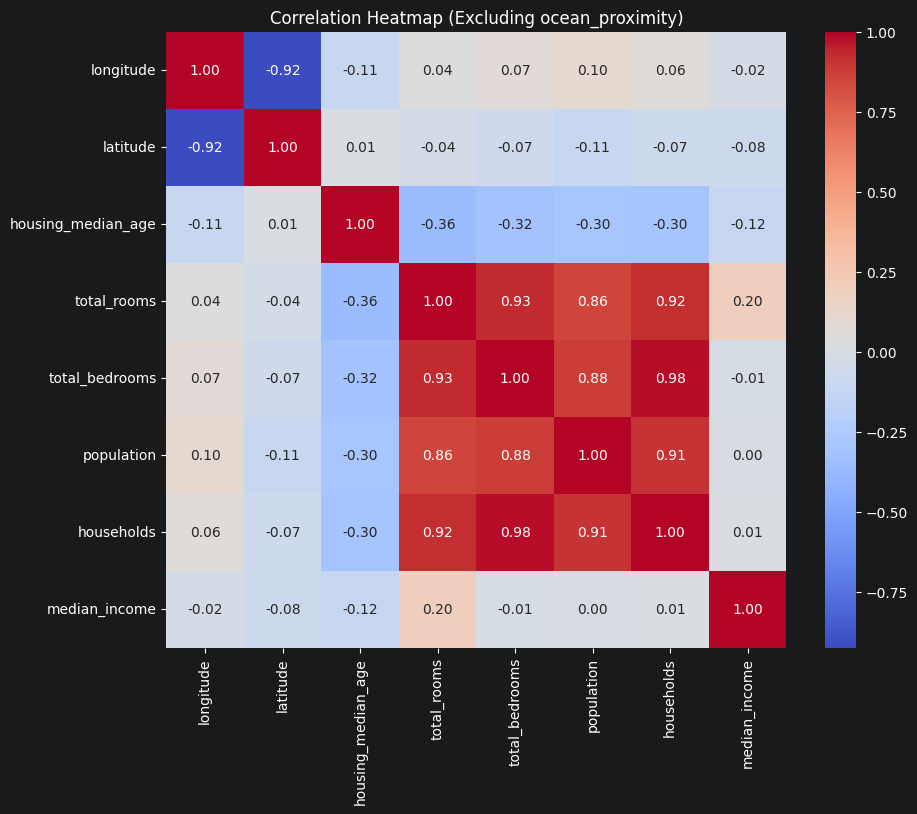

In [40]:
#Do NOT change the following code
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Excluding ocean_proximity)')
plt.show()

Based on the linear correlation matrix above, drop the features that are **highly correlated ( r > 0.85)**. Complete the code below so that only the features that are not highly correlated are kept.

Note:

*   Use the **y-axis** of the correlation matrix as the reference. Go from top to bottom: whenever a feature on the y-axis has r > 0.85 with another feature, keep the y-axis feature and remove the correlated one.
*   Don’t forget to drop the non-numerical columns as well as the label column (`median_house_value`).

In [57]:
### BEGIN SOLUTION
# X_Raw = data.select_dtypes(include='number').drop(columns=['latitude', 'total_bedrooms', 'population', 'households'], errors='ignore')
columns_to_drop = set()
# Since correlation matrix is symmetric, columns or rows don't matter, but ...
for row_name, row_data in correlation_matrix.iterrows():
    if row_name not in columns_to_drop:
        for col_column in correlation_matrix.columns:
            if col_column != row_name and col_column not in columns_to_drop:
                if abs(correlation_matrix.loc[row_name, col_column]) > 0.85:
                    columns_to_drop.add(col_column)

print("Dropping columns: ", columns_to_drop)
X_Raw = numeric_data.drop(columns=columns_to_drop)
### END SOLUTION
X_Raw.head()

Dropping columns:  {'households', 'population', 'total_bedrooms', 'latitude'}


,longitude,housing_median_age,total_rooms,median_income
0,-122.23000,41.00000,880.00000,8.32520
1,-122.22000,21.00000,7099.00000,8.30140
2,-122.24000,52.00000,1467.00000,7.25740
3,-122.25000,52.00000,1274.00000,5.64310
4,-122.25000,52.00000,1627.00000,3.84620


## Step 2: Form the features/Label

If you have completed all the steps correctly, you should now see only **4 features** remaining.

If we want to implement the **full second-degree polynomial** with 4 features, the equation should include:

*   each feature,
*   each feature squared, and
*   every pairwise multiplication of the features.

\begin{aligned}
y \approx & \ \theta_0
	•	\theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3 + \theta_4 x_4 \\
& + \theta_5 x_1^2 + \theta_6 x_2^2 + \theta_7 x_3^2 + \theta_8 x_4^2 \\
& + \theta_9 (x_1 x_2) + \theta_{10} (x_1 x_3) + \theta_{11} (x_1 x_4) \\
& + \theta_{12} (x_2 x_3) + \theta_{13} (x_2 x_4) + \theta_{14} (x_3 x_4)
\end{aligned}

In class, we created these polynomial features manually. Here, however, we will use a function called **`PolynomialFeatures`**. This function automatically generates all polynomial terms up to the specified degree. We simply provide it the input features, `X_raw`, and the desired degree, and it creates the expanded feature set for us.

In [42]:
#Do NOT change the following code
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_Raw)

If you have done everything correctly, the code above will create 15 columns, representing the **15 features** shown in the equation above. The order of these features is:


$$
\
1, \
x_1, \ x_2, \ x_3, \ x_4, \
x_1^2, \ x_1 x_2, \ x_1 x_3, \ x_1 x_4, \
x_2^2, \ x_2 x_3, \ x_2 x_4, \
x_3^2, \ x_3 x_4, \
x_4^2 \
$$

In [43]:
#Run this line of code to see the number of records in the dataset as well as the number of features created.
X_poly.shape

(20640, 15)

In the following code block, we will create a DataFrame named `X` using `X_poly` and add column names. We will also create a DataFrame `Y` from the label column, `median_house_value`. From this point on, working with the data will be much easier.



In [44]:
#Do NOT change the following code
X = pd.DataFrame(X_poly, columns=['1',
 'x1',
 'x2',
 'x3',
 'x4',
 'x1^2',
 'x1 x2',
 'x1 x3',
 'x1 x4',
 'x2^2',
 'x2 x3',
 'x2 x4',
 'x3^2',
 'x3 x4',
 'x4^2'])
Y=pd.DataFrame({'Price':data['median_house_value']})

In [45]:
#Run this code to see the features!
X.head()

,1,x1,x2,x3,x4,x1^2,x1 x2,x1 x3,x1 x4,x2^2,x2 x3,x2 x4,x3^2,x3 x4,x4^2
0,1.00000,-122.23000,41.00000,880.00000,8.32520,14940.17290,-5011.43000,-107562.40000,-1017.58920,1681.00000,36080.00000,341.33320,774400.00000,7326.17600,69.30896
1,1.00000,-122.22000,21.00000,7099.00000,8.30140,14937.72840,-2566.62000,-867639.78000,-1014.59711,441.00000,149079.00000,174.32940,50395801.00000,58931.63860,68.91324
2,1.00000,-122.24000,52.00000,1467.00000,7.25740,14942.61760,-6356.48000,-179326.08000,-887.14458,2704.00000,76284.00000,377.38480,2152089.00000,10646.60580,52.66985
3,1.00000,-122.25000,52.00000,1274.00000,5.64310,14945.06250,-6357.00000,-155746.50000,-689.86897,2704.00000,66248.00000,293.44120,1623076.00000,7189.30940,31.84458
4,1.00000,-122.25000,52.00000,1627.00000,3.84620,14945.06250,-6357.00000,-198900.75000,-470.19795,2704.00000,84604.00000,200.00240,2647129.00000,6257.76740,14.79325


## Step 3: Split the dataset

Import `train_test_split` from Scikit-learn and split the Features(X) and Label(Y) to 70% training subset and 30% test subset



In [46]:
### BEGIN SOLUTION
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.30,
)

### END SOLUTION

You should have 4 variables at this point: X_train, X_test, Y_train, Y_test

Step 4: Form Your Models

In this step, we will build two regression models to be trained later:

*   Import the `LinearRegression` class from `sklearn.linear_model`.
*   Create a linear regression model named `Model_Linear_Baseline` (to be trained on the raw features)
*   Create a linear regression model named `Model_Polynomial_Degree_2` (to be trained on the polynomial features in `X_poly`)

In [47]:
### BEGIN SOLUTION
from sklearn.linear_model import LinearRegression

Model_Linear_BaseLine = LinearRegression()
Model_Polynomial_Degree_2 = LinearRegression()

### END SOLUTION

## Step 5: Train your model

Train your linear model only using the first 5 features in **X_train**, ['1',
 'x1',
 'x2',
 'x3',
 'x4']


 and train your polynomial model using all features in **X_train** and your label **Y_train**

In [48]:
### BEGIN SOLUTION

Model_Linear_BaseLine.fit(X_train[['1', 'x1', 'x2', 'x3', 'x4']], Y_train)

Model_Polynomial_Degree_2.fit(X_train, Y_train)

### END SOLUTION

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 15)","[[ 0. , 0. ,-0.14,..., 0. , 1.18,26.23]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['1','x1','x2',...,'x3^2','x3 x4','x4^2']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[59307.05]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


## Step 6: Check the Coefficients

Print all 5 parameters; coefficients and intercept of the linear model <BR>
Print all 15 parameters; coefficients and intercept of the Polynomial model

In [49]:
### BEGIN SOLUTION

print("Linear Coef: ", Model_Linear_BaseLine.coef_)
print("Linear Int: ", Model_Linear_BaseLine.intercept_)

print("Poly Coef: ", Model_Polynomial_Degree_2.coef_)
print("Poly Int: ", Model_Polynomial_Degree_2.intercept_)

### END SOLUTION

Linear Coef:  [[ 0.00000000e+00 -9.60202403e+02  1.94387424e+03  3.71346856e+00
   4.25231695e+04]]
Linear Int:  [-137785.27655051]
Poly Coef:  [[ 0.00000000e+00  1.57628158e-03 -1.43070731e-01 -3.32391415e+00
   2.50514009e+00 -3.40268388e-01  1.62754534e+01  6.72225888e-02
  -3.00372054e+02  3.94114296e+01  5.77451116e-01  8.48207475e+01
   2.41126683e-05  1.17501169e+00  2.62336875e+01]]
Poly Int:  [59307.05053635]


## Step 7: Predictions

Use the trained models to predict the house prices for the trainig subset and test subset

In [50]:
### BEGIN SOLUTION

Baseline_test_predictions = Model_Linear_BaseLine.predict(
    X_test[['1', 'x1', 'x2', 'x3', 'x4']]
)
Baseline_train_predictions = Model_Linear_BaseLine.predict(
    X_train[['1', 'x1', 'x2', 'x3', 'x4']]
)

Polynomial_test_predictions = Model_Polynomial_Degree_2.predict(X_test)
Polynomial_train_predictions = Model_Polynomial_Degree_2.predict(X_train)

### END SOLUTION

## Step 8: Residual Analysis - Error


In this step, you will calculate the residuals (the absolute difference between predicted values and actual values) for both models:

**Baseline Model (Linear)**
*   For the testing subset, store the residuals in a variable named `Baseline_test_res`.
*   For the training subset, store the residuals in a variable named `Baseline_train_res`.

**Polynomial Model (Degree 2)**
*   For the testing subset, store the residuals in a variable named `Polynomial_test_res`.
*   For the training subset, store the residuals in a variable named `Polynomial_train_res`.

In [51]:
### BEGIN SOLUTION
Baseline_test_res = abs(Y_test.values - Baseline_test_predictions)
Baseline_train_res = abs(Y_train.values - Baseline_train_predictions)

Polynomial_test_res = abs(Y_test.values - Polynomial_test_predictions)
Polynomial_train_res = abs(Y_train.values - Polynomial_train_predictions)
### END SOLUTION

Run the following code block to visualize the distribution of the residuals. If you calculated the residuals correct, the plots should show up!

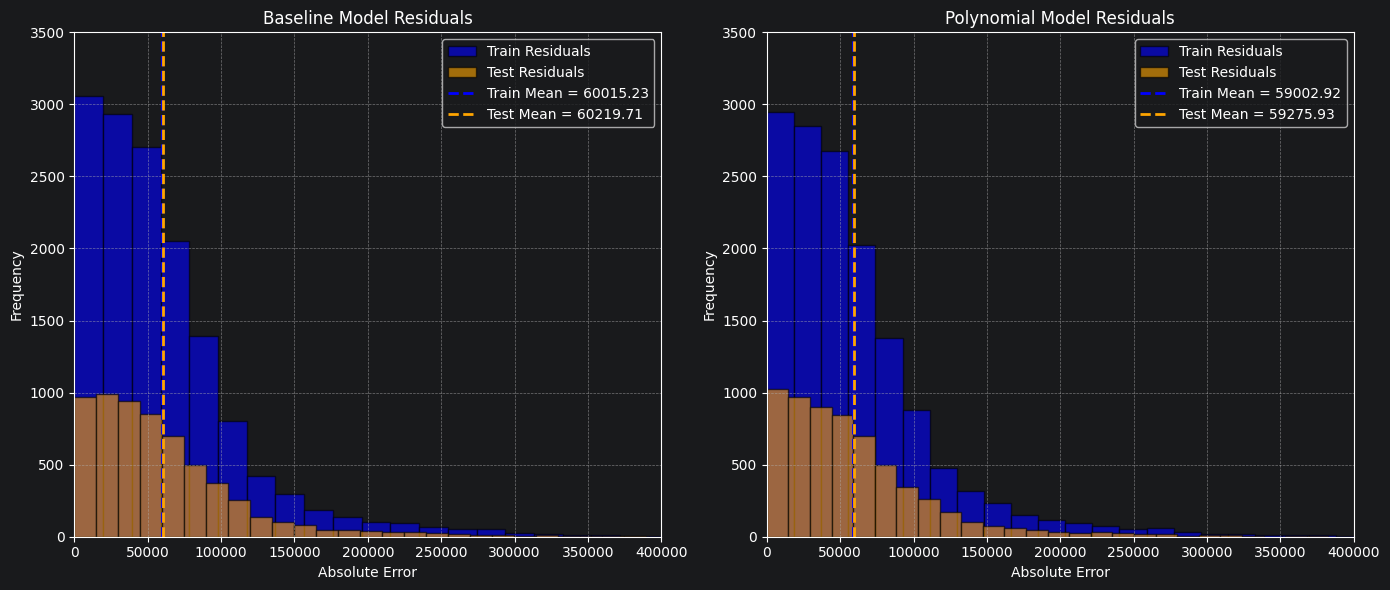

In [52]:
# Compute means (MAE) ~Mean Absolute Error
Baseline_train_mae = np.mean(Baseline_train_res)
Baseline_test_mae  = np.mean(Baseline_test_res)

Polynomial_train_mae = np.mean(Polynomial_train_res)
Polynomial_test_mae  = np.mean(Polynomial_test_res)

plt.figure(figsize=(14,6))

# --- Baseline model ---
plt.subplot(1,2,1)
plt.hist(Baseline_train_res, bins=30, alpha=0.6, color='blue', edgecolor='black', label='Train Residuals')
plt.hist(Baseline_test_res, bins=30, alpha=0.6, color='orange', edgecolor='black', label='Test Residuals')

# Mean error lines
plt.axvline(Baseline_train_mae, color='blue', linestyle='dashed', linewidth=2,
            label=f"Train Mean = {Baseline_train_mae:.2f}")
plt.axvline(Baseline_test_mae, color='orange', linestyle='dashed', linewidth=2,
            label=f"Test Mean = {Baseline_test_mae:.2f}")

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Baseline Model Residuals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Fix axes
plt.xlim(0, 400000)
plt.ylim(0, 3500)

# --- Polynomial model ---
plt.subplot(1,2,2)
plt.hist(Polynomial_train_res, bins=30, alpha=0.6, color='blue', edgecolor='black', label='Train Residuals')
plt.hist(Polynomial_test_res, bins=30, alpha=0.6, color='orange', edgecolor='black', label='Test Residuals')

# Mean error lines
plt.axvline(Polynomial_train_mae, color='blue', linestyle='dashed', linewidth=2,
            label=f"Train Mean = {Polynomial_train_mae:.2f}")
plt.axvline(Polynomial_test_mae, color='orange', linestyle='dashed', linewidth=2,
            label=f"Test Mean = {Polynomial_test_mae:.2f}")

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Polynomial Model Residuals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Fix axes
plt.xlim(0, 400000)
plt.ylim(0, 3500)

plt.tight_layout()
plt.show()

**<font color=blue>Do you see the Improvement?!**

##Step 9: Mean Squared Error (MSE) Analysis

In this step, you will calculate the Mean Squared Error (MSE) for both models:

**Baseline Model (Linear)**
*   For the testing subset, compute the MSE and store it in a variable named `Baseline_test_mse`.
*   For the training subset, compute the MSE and store it in a variable named `Baseline_train_mse`.

**Polynomial Model (Degree 2)**
*   For the testing subset, compute the MSE and store it in a variable named
`Polynomial_test_mse`.
*   For the training subset, compute the MSE and store it in a variable named `Polynomial_train_mse`.



In [55]:
### BEGIN SOLUTION
from sklearn.metrics import mean_squared_error

Baseline_test_mse = mean_squared_error(Y_test.values, Baseline_test_predictions)
Baseline_train_mse = mean_squared_error(Y_train.values, Baseline_train_predictions)

Polynomial_test_mse = mean_squared_error(Y_test.values, Polynomial_test_predictions)
Polynomial_train_mse = mean_squared_error(Y_train.values, Polynomial_train_predictions)

### END SOLUTION

Run the following code to visualize the MSE improvement!

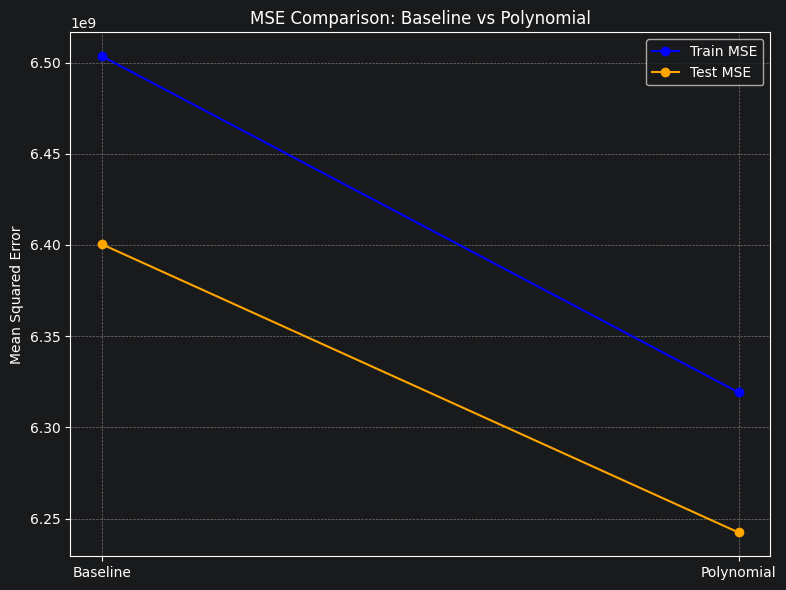

In [56]:
# Models
models = ["Baseline", "Polynomial"]

# Train and Test MSE values
train_mse = [Baseline_train_mse, Polynomial_train_mse]
test_mse  = [Baseline_test_mse, Polynomial_test_mse]

# Plot
plt.figure(figsize=(8,6))
plt.plot(models, train_mse, marker='o', color='blue', label='Train MSE')
plt.plot(models, test_mse, marker='o', color='orange', label='Test MSE')

plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison: Baseline vs Polynomial")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()